# Rush Impact

Compares weekday rush-window performance against non-rush periods.

In [1]:
from pathlib import Path
import importlib.util
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "analysis"))

spec = importlib.util.spec_from_file_location(
    "rush_impact",
    PROJECT_ROOT / "analysis" / "rush-impact.py",
)
rush_impact = importlib.util.module_from_spec(spec)
spec.loader.exec_module(rush_impact)

DB = PROJECT_ROOT / "data" / "foli.db"
TIMEZONE = "Europe/Helsinki"
RUSH_WINDOWS = ["07:00-09:00", "15:00-18:00"]
INCLUDE_WEEKENDS = False
MIN_OBSERVATIONS = 50
LIMIT = 10
QUALITY_MODE = "conservative"
BUCKET = "trip-stop"

In [2]:
class Args:
    db = DB
    timezone = TIMEZONE
    rush_window = RUSH_WINDOWS
    include_weekends = INCLUDE_WEEKENDS
    min_observations = MIN_OBSERVATIONS
    limit = LIMIT
    quality_mode = QUALITY_MODE
    exclude_stop_call_disagreement = False
    bucket = BUCKET

df = rush_impact.load_observations(Args)
impact = rush_impact.build_rush_impact(Args, df)
impact

,line_ref,line_name,bucket_count_non_rush,bucket_count_rush,raw_poll_count_non_rush,raw_poll_count_rush,median_delay_min_non_rush,median_delay_min_rush,rush_median_delay_lift_min,p90_delay_min_non_rush,p90_delay_min_rush,rush_p90_delay_lift_min,pct_over_5_min_late_non_rush,pct_over_5_min_late_rush,rush_over_5_min_late_pct_point_lift
43,612,612,422,975,915,2134,0.22,7.48,7.26,4.27,16.55,12.27,6.16,64.62,58.45
45,615,615,1014,2185,1891,4277,1.25,4.57,3.31,6.70,16.14,9.44,16.37,47.96,31.59
58,72,72,2146,1138,3683,2034,1.34,4.10,2.76,5.67,10.87,5.21,13.79,41.21,27.42
61,721,721,1428,774,3528,1532,1.12,3.52,2.41,4.30,8.03,3.73,7.00,37.60,30.59
49,701,701,1011,2149,2849,6090,0.13,1.50,1.37,2.80,6.39,3.59,3.96,15.96,12.00
10,220,220,33634,8841,84631,23140,0.41,2.89,2.48,3.89,7.37,3.47,5.09,25.98,20.89
67,77,77,886,1306,2156,2324,-4.22,0.24,4.47,-0.56,2.83,3.39,1.13,0.84,-0.29
75,903,903,315,680,1590,1989,-0.70,0.00,0.70,3.74,7.05,3.31,5.08,18.82,13.74
103,P1,P1,574,290,2965,1593,-0.53,0.00,0.53,1.40,4.25,2.85,1.22,8.97,7.75
62,722,722,7793,3395,15020,6398,1.30,2.42,1.12,5.43,8.22,2.78,12.18,22.09,9.91


Text(0, 0.5, 'Line')

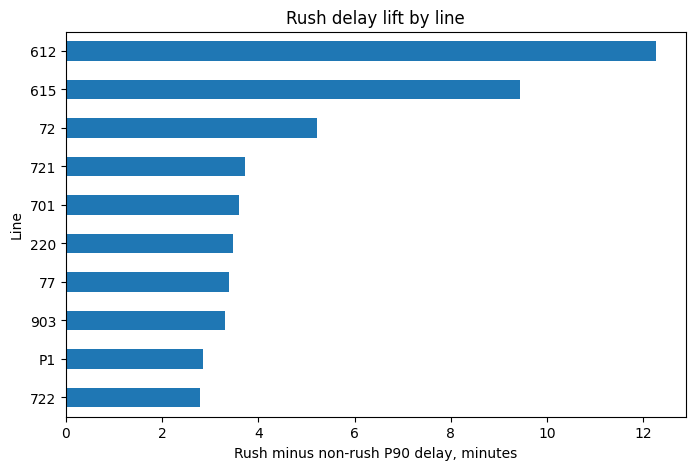

In [3]:
ax = impact.sort_values("rush_p90_delay_lift_min").plot.barh(
    x="line_ref",
    y="rush_p90_delay_lift_min",
    legend=False,
    figsize=(8, 5),
    title="Rush delay lift by line",
)
ax.set_xlabel("Rush minus non-rush P90 delay, minutes")
ax.set_ylabel("Line")